# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
#pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [2]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [3]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
# display(X_raw.describe().T)
X_raw.info()
print("\nSố dòng duplicate:", X_raw.duplicated().sum())
print("\nSố giá trị 0:")
display((X_raw==0).sum())
display(X_raw.describe())



<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicassen        440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB

Số dòng duplicate: 0

Số giá trị 0:


Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,"12,000.30","5,796.27","7,951.28","3,071.93","2,881.49","1,524.87"
std,"12,647.33","7,380.38","9,503.16","4,854.67","4,767.85","2,820.11"
min,3.00,55.00,3.00,25.00,3.00,3.00
25%,"3,127.75","1,533.00","2,153.00",742.25,256.75,408.25
50%,"8,504.00","3,627.00","4,755.50","1,526.00",816.50,965.50
75%,"16,933.75","7,190.25","10,655.75","3,554.25","3,922.00","1,820.25"
max,"112,151.00","73,498.00","92,780.00","60,869.00","40,827.00","47,943.00"


- Mỗi dòng dữ liệu đại diện cho một khách hàng, các features có ý nghĩa cho bài toán segmentation là Fresh, Milk, Grocery, Frozen, Dêtrgents_Paper và Delicassen, giúp ta nắm được thói quen, xu hướng mua sắm của khách hàng.
- Dữ liệu không bị thiếu, không trùng lặp, không có giá trị 0 và kiểu dữ liệu đã ổn. Có sự xuất hiện của các outliers ở các cột (ví dụ ở cột fresh thì Q3 chỉ là 16,933 nhưng max lên tới 112,151).
- Channel nên được dùng ở bước cuối sau khi đã gom cụm xong, là context để kiểm tra coi các cụm có trùng khớp với kênh hay vùng cụ thể nào không, không nên đặt vào input clustering ngay từ đầu vì chúng ta muốn tìm ra các cụm khách hàng dựa trên hành vi chi tiêu, nếu cung cấp sẵn nhãn channel thì mô hình sẽ chỉ chia theo nhãn đã có này, làm mất ý nghĩa của cấu trúc ẩn.
- Với dữ liệu chi tiêu, các cụm tìm được sẽ hữu ích khi dựa vào nó, chúng ta có thể chuyển hóa dữ liệu thành những hành động cụ thể: mỗi nhóm khách hàng sẽ có những chiến lược tiếp thị, chăm sóc, giảm giá riêng biệt,...

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

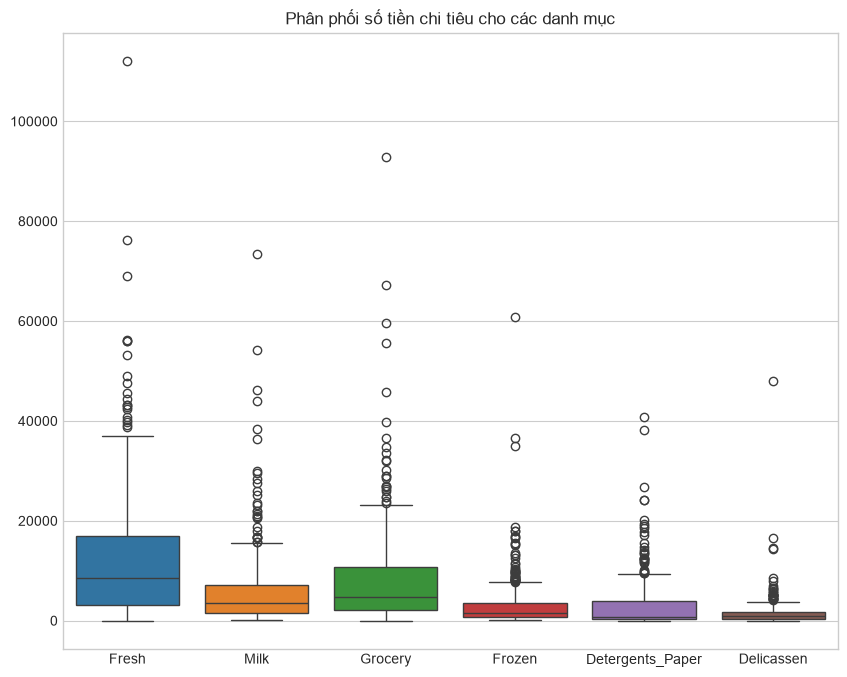

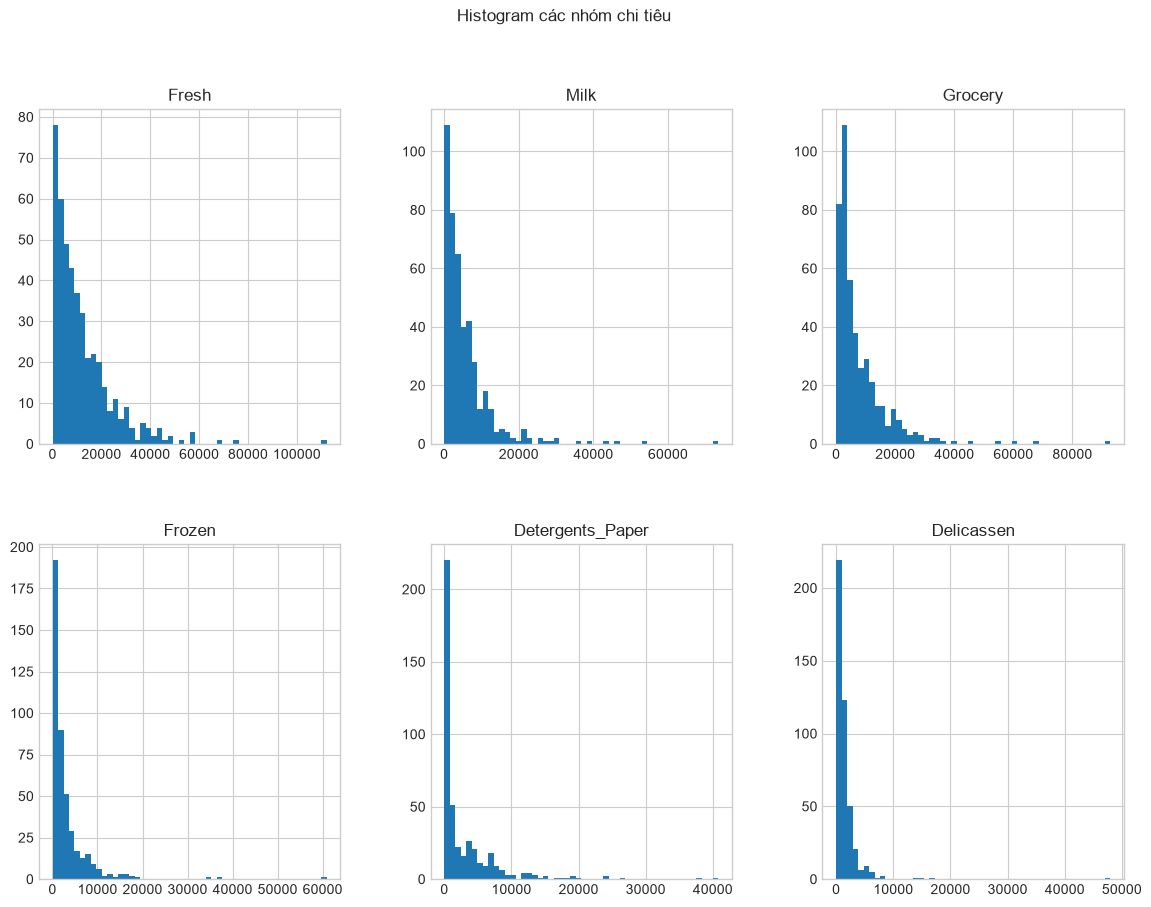

In [4]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.boxplot(data=X_raw)
plt.title("Phân phối số tiền chi tiêu cho các danh mục")
plt.show()

X_raw.hist(bins=50, figsize=(14,10), layout=(2,3))
plt.suptitle("Histogram các nhóm chi tiêu")
plt.show()




- Với biểu đồ boxplot: Dải giá trị ở nhóm Fresh và Grocery khá lớn (lên đến hơn 100000 ở Fresh) trong khi ở 3 nhóm cuối thì thấp hơn đáng kể (lớn nhất chỉ khoảng 50000), cần phải scale. Các outliers cũng xuất hiện nhiều ở một số nhóm.
- Về phân phối riêng của từng nhóm: Tất cả đều bị lệch phải rất nặng, có thể phải nén long tail.

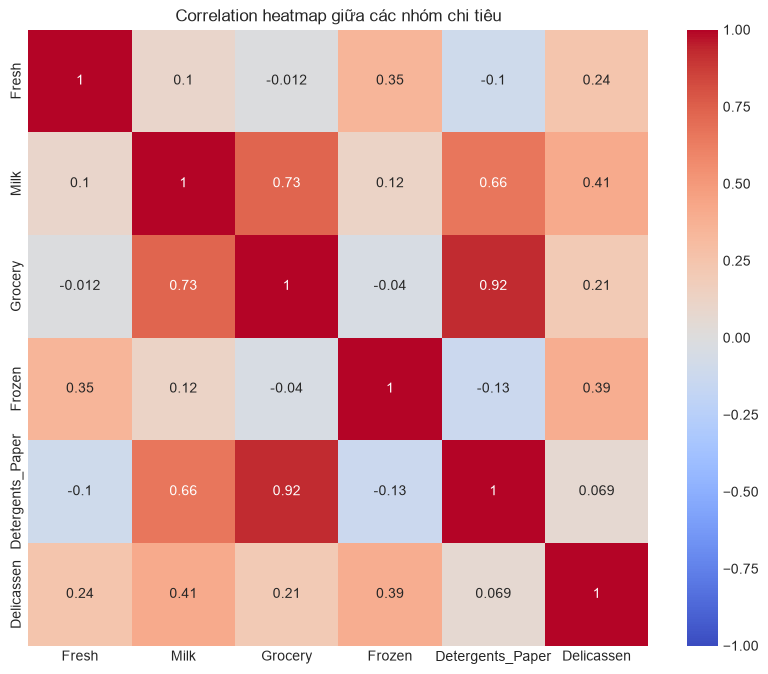

In [5]:
plt.figure(figsize=(10,8))
corr = X_raw.corr()
sns.heatmap(data=corr,annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation heatmap giữa các nhóm chi tiêu")
plt.show()

- Có sự tương quan dương mạnh giữa grocery, detergents_paper và milk, gợi ý có tồn tại nhóm khách hàng hay mua/nhập sữa cùng tạp hóa, chất tẩy rửa.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [6]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))

X_log = np.log1p(X_raw)
scaler = StandardScaler()
X_model = scaler.fit_transform(X_log)
X_model_df = pd.DataFrame(X_model, columns = X_raw.columns)
display(X_model_df.describe().round(2))

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-5.00,-3.79,-6.36,-3.16,-3.17,-4.09
25%,-0.47,-0.73,-0.69,-0.54,-0.73,-0.51
50%,0.21,0.07,0.02,0.02,-0.05,0.16
75%,0.68,0.70,0.75,0.68,0.87,0.65
max,1.97,2.86,2.70,2.90,2.24,3.18


- Để xử lý skew, outlier: sử dụng biến đổi log1p để nén các điểm outlier lại, làm giảm sử lệch phải mà không cần xóa dữ liệu (các nhóm đều bị lệch phải nặng). Sau đó, sử dụng StandardScaler để đưa các đặc trưng về cùng một thang đo, giúp các trọng số của các biến sẽ ngang nhau khi đo khoảng cách.
- Matrix được dùng để fit model là X_model vì: dữ liệu của X_raw như đã thấy ở trên, bị lệch rất nhiều và sự chênh lệch giữa thang đo của các biến cũng là lớn nên cần đưa X_raw qua các phép biến đổi và scale lại thành X_model. Ngoài ra thì sử dụng X_model còn bảo đảm việc dữ liệu gốc được bảo toàn để tính profile cụm theo đơn vị tiền thực tế.
- Một trade-off của lựa chọn preprocessing: các con số trong X_model đã được qua biến đổi và scale nên sẽ mất đi khả năng diễn giải trực tiếp, không còn mang ý nghĩa giá trị tiền tệ như ban đầu, không thể trực tiếp đọc hành vi khách hàng của các cụm.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [7]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)

kmeans_model = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=15)
labels_kmeans = kmeans_model.fit_predict(X_model)
print("K-Means (K=3):")
print("Kích thước cụm:\n",pd.Series(labels_kmeans).value_counts().sort_index())


agg_model = AgglomerativeClustering(n_clusters=3, linkage= 'ward')
labels_agg = agg_model.fit_predict(X_model)
print("\nHierarchical (Agglomerative):")
print("Kích thước cụm:\n",pd.Series(labels_agg).value_counts().sort_index())


K-Means (K=3):
Kích thước cụm:
 0     80
1    147
2    213
Name: count, dtype: int64

Hierarchical (Agglomerative):
Kích thước cụm:
 0    262
1     53
2    125
Name: count, dtype: int64


-Input và tham số: cả hai mô hình đều sử dụng X_model. K-Means chọn K=3, còn Agglomerative thì chọn linkage là ward.

-Trực quan thì dường như size cụm của Agglomerative lệch nhau đáng kể (53 so với 262), còn K-Means thì size của các cụm có chênh lệch nhưng không quá lớn, không có nhóm nào quá nhỏ và cũng không có nhóm nào ôm quá nhiều điểm dữ liệu nên em nghĩ đây là evidence để ủng hộ cho K-Means.

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [8]:
print("K-Means:")
print(f"Silhouette Score: {silhouette_score(X_model, labels_kmeans):.2f}\nDavies-Bouldin Score: {davies_bouldin_score(X_model, labels_kmeans):.2f}")
print("\nHierarchical:")
print(f"Silhouette Score: {silhouette_score(X_model, labels_agg):.2f}\nDavies-Bouldin Score: {davies_bouldin_score(X_model, labels_agg):.2f}")


K-Means:
Silhouette Score: 0.26
Davies-Bouldin Score: 1.34

Hierarchical:
Silhouette Score: 0.25
Davies-Bouldin Score: 1.54


Tổng quan thì Silhouette Score chênh lệnh nhỏ nhưng DB Score của K-Means thấp hơn đáng kể so với Hierarchical.

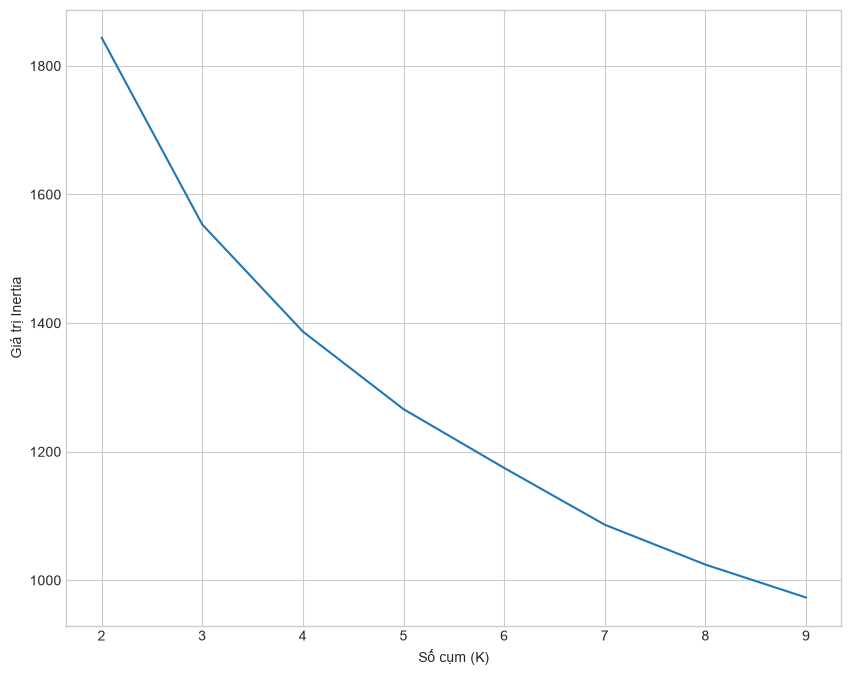

In [9]:
inertial =[]
k_range = range(2,10)
for k in k_range:
    model = KMeans(n_clusters= k, random_state=RANDOM_STATE, n_init=15)
    model.fit(X_model)
    inertial.append(model.inertia_)
plt.figure(figsize=(10,8))
plt.plot(k_range, inertial)
plt.xlabel("Số cụm (K)")
plt.ylabel("Giá trị Inertia")
plt.xticks(k_range)
plt.show()

Trên biểu đồ thể hiện chỉ số Inertia với từng giá trị K thì em thấy ở mức 3, 4 thì dường như độ dốc sẽ thoải dần. 

Silhouette Score và DB Score cũng ở mức tương đối, ranh giới các cụm vẫn sẽ còn sự chồng lấn nhưng điều này phản ánh đúng dữ liệu hơn và với số cụm là 3 thì tính khả thi để triển khai các hành động cũng sẽ ở mức tốt vì sẽ không gặp vấn đề khó trong việc phân ra quá nhiều chiến lược, hay các chiến lược tập trung vào mẫu quá nhỏ hoặc quá bao quát.

Vậy nên, K-Means có thể là lựa chọn tốt hơn trong trường hợp này.


In [10]:
rnd_state_list = [67, 6767, 6677, 7667, 676767]
ari_scores = []
for state in rnd_state_list:
    test_model = KMeans(n_clusters=3, random_state=state, n_init = 10)
    test_labels = test_model.fit_predict(X_model)
    ari = adjusted_rand_score(labels_kmeans, test_labels)
    ari_scores.append(ari)
print(f"ARI trung bình: {np.mean(ari_scores):.3f}")


ARI trung bình: 0.982


Mô hình không bị thay đổi nhiều với việc khởi tạo ngẫu nhiên.

Tổng kết: Model K-Means với các tham số: n_cluster = 3, random_state = 42, n_init = 15

Evidence mạnh nhất: Size giữa các cụm khá ổn, chênh lệch không quá nhiều, không quá bao quát và cũng không phân mảnh.

Em vẫn chưa thấy chắc chắn với 2 số điểm của 2 metrics Silouette Score và DB Score lắm nhưng vẫn chọn vì em nghĩ K=3 thì cụm ổn định và có thể diễn giải tốt được.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


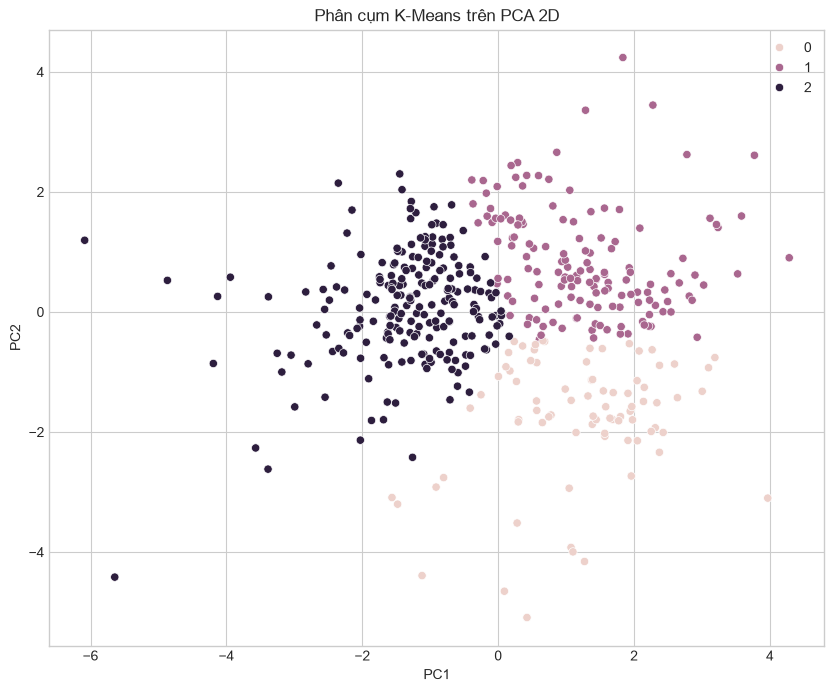

In [11]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)

coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)
plt.figure(figsize=(10,8))
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue= labels_kmeans)
plt.title("Phân cụm K-Means trên PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Biểu đồ PCA 2D cung cấp góc nhìn trực quan hơn về xu hướng phân tách của 3 cụm, các nhóm dường như được khoanh vùng rõ ràng, cho thấy việc mô hình đã tìm được các mẫu riêng biệt.

Cụ thể hơn, trục PC1 phân tách cụm 2 hoàn toàn sang bên trái, PC1 thì phân tách cụm 0 và 1 rõ hơn. Cụm 2 dường như co lại chặt chẽ hơn so với 2 cụm còn lại. Hình ảnh cho thấy rõ sự chồng lấn khá rõ giữa cả 3 cụm, giải thích cho Silhouhette Score chỉ đạt 0.26.

Nhưng thực tế thì dữ liệu được fit trên matrix 6 chiều, đồng nghĩa với việc khi chiếu trên hình vẽ 2D thì những mẫu dữ liệu chưa chắc đã thực sự phân tách hay co cụm, ta chỉ dựa vào để có một góc nhìn trực quan, bao quát và dễ hiểu hơn chứ không thể chỉ dùng một mình biểu đồ để làm bằng chứng khẳng định hai điểm thật sự gần hay xa nhau.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

In [12]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()

X_raw['Cluster'] = labels_kmeans
cluster_profile = X_raw.assign(cluster=labels_kmeans).groupby('cluster').median()
cluster_profile['Size'] = X_raw['Cluster'].value_counts()
display(cluster_profile)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster,Size
cluster,,,,,,,,
0,"1,492.50","6,300.50","10,502.50",376.00,"4,217.50",434.50,0.00,80
1,"12,126.00","7,184.00","9,965.00","2,005.00","3,378.00","2,005.00",1.00,147
2,"9,612.00","1,601.00","2,155.00","2,121.00",274.00,686.00,2.00,213


Tính giá trị chi tiêu cho những ngành hàng của từng cụm bằng trung vị: vì dữ liệu X_raw ban đầu có chứa các outliers ở các nhóm hàng nên dùng trung vị thay vì trung bình để ít bị ảnh hưởng hơn.

Tên gọi:
- Cụm 0: Tiệm tạp hóa/ Siêu thị mini/ Người tiêu dùng thông thường
  + Chi tiêu chủ yếu cho grocery (10,502), milk và detergents_paper. Còn những nhóm hàng fresh và frozen thì thấp hơn.
  + Action Hypothesis: nếu triển khai những gói chiết khấu theo số lượng lớn cho combo grocery và paper_detergents thì tỉ lệ giữ chân khách hàng có thể tăng.
- Cụm 1: Siêu thị lớn/ Đối tác buôn bán
  + Đây là nhóm có ngân sách lớn nhất trong cả 3, chi tiêu ở mọi danh mục đều vượt trội hơn. Đặc biệt nhiều ở fresh và grocery, nhóm delicassen được tiêu thụ gấp 3-4 lần các cụm khác.
  + Action Hypothesis: Thiết lập các hợp đồng cung ứng dài hạn kèm các dịch vụ ưu tiên vận chuyển, chiết khấu cao thì có thể đảm bảo được nguồn doanh thu lớn, đều đặn và liên tục.

- Cụm 2: Nhà hàng/Quán ăn truyền thống
  + Ngân sách chủ yếu là nguyên liệu chế biến: fresh và frozen, chi tiêu cho detergents_paper cực kì thấp, chứng tỏ họ không kinh doanh hay bán lẻ mặt hàng này.
  + Action Hypothesis: Thiết kế dịch vụ cung ứng nguyên liệu tươi sống định kì vào khung giờ sớm để các nhà hàng chuẩn bị được sớm hơn, tần suất đặt hàng có thể tăng.

Dữ liệu còn thiếu trước khi biến action hypothesis thành quyết định chắc chắn:
- Tần suất đặt hàng, khoảng cách giữa mỗi lần mua và thời gian/ khung giờ nhận hàng ưu tiên.
- Lịch sử phản hồi của khách hàng về các chiến dịch trước đây trong quá khứ để biết họ nhạy cảm, ưu tiên về dịch vụ hay khuyến mãi.
- Dữ liệu về kho bãi, nhân công, tài xế,... để đánh giá, kiểm tra và đảm bảo chuỗi cung ứng có thể đáp ứng được khối lượng giao/nhận hàng lớn vào các thời điểm.
- Biên lợi nhuận của từng danh mục để tính toán mức chiết khấu phù hợp.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.


1. Segmentation này có thể áp dụng ở mức thử nghiệm giới hạn. Như đã đề cập ở trên, các chỉ số đánh giá Silhouette và DB Score chỉ ở mức vừa phải, dữ liệu còn thiếu các yếu tố như: thời gian, tần suất nên ta nên thí điểm trên một nhóm nhỏ thay vì triển khai đại trà ngay lập tức.
2. Quyết định sử dụng K-Means với K = 3, dữ liệu đã được biến đổi log1p và scale. Evidence: Kích thước của các cụm ở mức hợp lý, số K được chọn nằm trong khoảng elbow của Inertia, chỉ số Silhouette và DB Score tốt hơn so với Hierarchical và độ ổn định của mô hình cũng tốt thông qua chỉ số ARI.
3.
- Có ranh giới rõ ràng giữa danh mục chi tiêu chủ yếu của cụm 0 và cụm 2
- Chỉ ra được nhóm khách hàng trọng điểm: cụm 1 với sức mua, mức độ chi tiêu khổng lồ.
4.
- Action: Thử nghiệm chào bán combo mua sỉ với chiết khấu cao cho danh mục grocery và detergents_paper, áp dụng giới hạn trên 25 khách hàng ngẫu nhiên của cụm 0.
- Đánh giá: dựa trên tỉ lệ chốt đơn hàng và sự gia tăng giá trị trung bình trên mỗi đơn hàng so với trước khi có chiến dịch.
5. Dữ liệu còn thiếu vắng rất nhiều các yếu tố quan trọng, mang tính quyết định cao khác như: biên lợi nhuận các danh mục, chi phí vận chuyển, kho bãi, tần suất của khách hàng,...

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.